## Hypothesis testing from the beginning

### 1. Why do we need it?

Your 86,637 bookings are a **sample** of what the hotels' guests do. We want conclusions that hold in general, not only in this dataset. But samples are affected by luck. Here is the problem:

> City Hotel cancels 30.2% and Resort Hotel 23.7%. Is that a **real difference between the hotels**, or just **random variation** that would shrink if we looked at different bookings?

Hypothesis testing is the method that answers this fairly, with a number instead of a guess.

**A coin example.** You flip a coin and want to know if it is biased:

| Result | Chance of getting this many heads or more with a **fair** coin | Verdict |
|---|---|---|
| 6 heads out of 10 | 37.7% | Ordinary luck |
| 60 out of 100 | 2.8% | Suspicious |
| 600 out of 1000 | 0.000000014% (1.4e-10) | The coin is almost certainly biased |

The **same 60% heads** looks normal or impossible depending on how much data you have. A hypothesis test measures exactly that.

### 2. What is a hypothesis?

A hypothesis is a **testable claim about the population**, written as two competing statements:

| | Name | Meaning | Our hotel example |
|---|---|---|---|
| **H0** | **Null hypothesis** | Nothing is going on: no difference, no effect, no relationship | Both hotels have the same cancellation rate |
| **H1** | **Alternative hypothesis** | The claim we suspect is true | The rates are different |

**Why start by assuming H0?** It works like a court case: the defendant is **innocent until proven guilty**. We assume "no effect" and only reject it if the evidence is strong.

We don't prove H0, and we never say "we accept H0". We either:

- **Reject H0** → enough evidence
- **Fail to reject H0** → not enough evidence

### 3. The idea behind every test: the null distribution

1. **Imagine the world where H0 is true.** Even there, two samples won't match exactly. Luck makes them differ a little.
2. Take one number that summarises our data's gap, the **test statistic** (Z, t, F or chi-square).
3. In the H0 world, that statistic would take many values. Most are near the middle, and a few are extreme. That spread is the **null distribution**.
4. Ask: **where does our real number land on that curve?**
   - In the crowded middle → ordinary luck, so we can't reject H0.
   - In the far tail → luck is an unlikely explanation, so we reject H0.
5. The **p-value** is the probability of getting a result **at least this extreme if H0 were true**.

**p-value, in plain words:**

> "If the hotels really had identical cancellation rates, how often would a sample show a gap this big?"

Our answer was **2.77e-96**, so essentially never.

### 4. The rule for deciding: alpha

We set a cut-off before testing, the **significance level α = 0.05**:

- **p < 0.05** → reject H0 → statistically significant
- **p ≥ 0.05** → fail to reject H0 → not statistically significant

There are two ways to be wrong:

| | H0 is actually true | H0 is actually false |
|---|---|---|
| **We reject H0** | ❌ **Type I error** (false alarm). Chance = α = 5% | ✅ Correct |
| **We don't reject H0** | ✅ Correct | ❌ **Type II error** (missed a real effect) |

Choosing α = 0.05 means we accept a **5% risk of a false alarm**.

### 5. One-sided vs two-sided

- **Two-sided:** "Are they **different**?" H1 uses **≠**. The 5% rejection zone is split across both tails.  
  → **H1: Hotels**

- **One-sided:** "Is A **higher** than B?" H1 uses **>** or **<**. The whole 5% goes into one tail.  
  → **H3: Online TA**

Decide this **before** you look at the results, never after.

### 6. Statistically significant is not the same as important

With 86,637 bookings, even a tiny difference can get a very small p-value.

So for every test we also report the **effect size** — the actual size of the difference.

Examples:

- 6.5 percentage points
- 35 days
- Cohen's d

The simple idea is:

> **p-value → Is the difference statistically real?**  
> **Effect size → Is the difference large enough to matter?**

### 7. How to pick the test: your whiteboard tree

Ask three questions, in this order:

1. **What kind of data?**
   - Proportion (%)
   - Counts in categories
   - Mean
   - Variance

2. **How many groups?**
   - 1 group
   - 2 groups
   - More than 2 groups

3. **Any extra detail?**
   - Independent or paired groups
   - Number of factors
   - Other assumptions

### 8. Our 5 hypotheses, in plain words

| # | Business question | H0 (nothing going on) | H1 (what we suspect) | Test |
|---|---|---|---|---|
| **H1** | Do hotels differ in cancellations? | Same cancellation rate | Different rate | **2 prop test** |
| **H2** | Do cancelled bookings book earlier? | Same average lead time | Cancelled have longer average lead time | **2 sample t test** (after a **2 var test**) |
| **H3** | Is Online TA riskier? | Same cancellation rate as other channels | Online TA's rate is higher | **2 prop test** (one-sided) |
| **H4** | Does deposit type relate to cancellation? | Deposit type and cancellation are unrelated | They are related | **Degree of association (chi-square)** |
| **H5** | Does price differ by season? | All seasons have the same average ADR | At least one season differs | **One-way ANOVA** |

### Each test follows the same 5-step recipe

1. State **H0 and H1**.
2. Choose **α = 0.05** and the test.
3. Compute the **test statistic and p-value**.
4. Report the **effect size**.
5. Make the decision and explain the **business meaning**.

### 9. The notebook plan (`04_hypothesis_testing.ipynb`)

| Cell | Content |
|---|---|
| 1 | Setup |
| 2 | **Intuition demo:** See the null distribution built from your own data |
| 3 | H1 — 2 prop test |
| 4 | H2 — 2 var test, then 2 sample t test |
| 5 | H3 — 2 prop test, one-sided |
| 6 | H4 — Degree of association |
| 7 | H5 — One-way ANOVA |
| 8 | Summary table of all results |

If you already have old cells in this notebook, delete them and start fresh with this order.

You can reuse the **H1, H2 and H3 code** already provided because those tests are already part of your hypothesis-testing plan.

In [14]:
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from pathlib import Path

ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "processed" / "hotel_bookings_clean.csv"

df = pd.read_csv(DATA_PATH)

# our rule: if p-value is below alpha, we reject H0
alpha = 0.05

print(df.shape)
print("Significance level (alpha):", alpha)

(86637, 42)
Significance level (alpha): 0.05


Real gap (City - Resort), percentage points: 6.5
Smallest fake gap: -1.2
Largest fake gap: 1.04
Typical wobble (std of fake gaps): 0.31
Shuffles with a gap as big as the real one: 0 out of 2000
Real gap in 'wobbles': 21.0


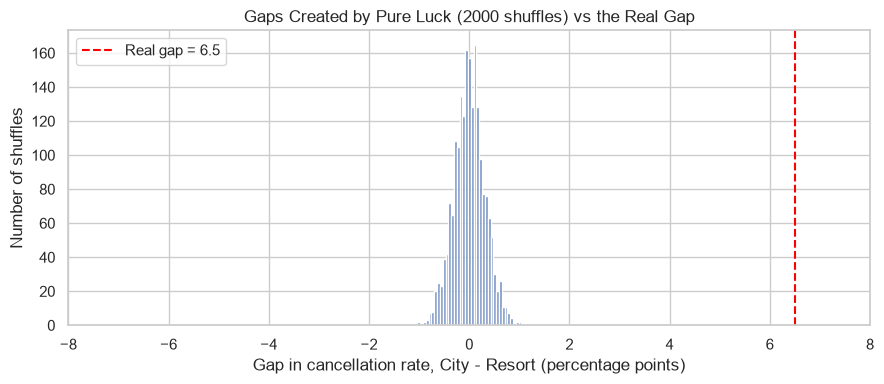

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

VISUALS_DIR = ROOT / "visuals"
sns.set_theme(style="whitegrid")

# ======================================================================
# INTUITION DEMO (a teaching tool, not one of our 5 reported tests)
# ======================================================================
# H0 says: the hotel has NO effect on cancellation.
# If that is true, the labels "City" and "Resort" are meaningless.
# So we can shuffle them randomly and any gap we see is pure luck.
# Repeat 2000 times -> we get the NULL DISTRIBUTION, the spread of gaps
# that luck alone creates. Then we ask: where does our REAL gap land?

np.random.seed(42)    # makes the shuffles repeatable

# Step 1: put the two columns into simple arrays
is_city = (df["hotel"] == "City Hotel").values      # True = City, False = Resort
cancelled = df["is_canceled"].values                # 1 = cancelled, 0 = kept

# Step 2: the REAL gap in cancellation rates (City minus Resort)
observed_gap = cancelled[is_city].mean() * 100 - cancelled[~is_city].mean() * 100
print("Real gap (City - Resort), percentage points:", round(observed_gap, 2))

# Step 3: shuffle the hotel labels 2000 times and measure the gap each time
fake_gaps = []
for i in range(2000):
    shuffled = np.random.permutation(is_city)       # random re-assignment of labels
    gap = cancelled[shuffled].mean() * 100 - cancelled[~shuffled].mean() * 100
    fake_gaps.append(gap)
fake_gaps = np.array(fake_gaps)

# Step 4: how big can a gap created by pure luck get?
print("Smallest fake gap:", round(fake_gaps.min(), 2))
print("Largest fake gap:", round(fake_gaps.max(), 2))
print("Typical wobble (std of fake gaps):", round(fake_gaps.std(), 2))
print("Shuffles with a gap as big as the real one:", (np.abs(fake_gaps) >= abs(observed_gap)).sum(), "out of 2000")
print("Real gap in 'wobbles':", round(observed_gap / fake_gaps.std(), 1))

# Step 5: draw the null distribution and mark the real gap
plt.figure(figsize=(9, 4))
sns.histplot(fake_gaps, bins=40)
plt.axvline(observed_gap, color="red", linestyle="--", label=f"Real gap = {observed_gap:.1f}")
plt.xlim(-8, 8)
plt.title("Gaps Created by Pure Luck (2000 shuffles) vs the Real Gap")
plt.xlabel("Gap in cancellation rate, City - Resort (percentage points)")
plt.ylabel("Number of shuffles")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "11_null_distribution_shuffle.png")
plt.show()